# EEG-Visual Feature Correlation Explorer

Verify that EEG signals contain decodable information about movie visual features
before running expensive model benchmarks.

**Analyses:**
1. Band power (delta/theta/alpha/beta/gamma) correlation with visual features
2. Temporal alignment check: EEG power vs feature time series
3. ERP to scene cuts (visual evoked potential sanity check)
4. Binary classification baseline (median split)

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sp_signal
from scipy.stats import pearsonr, spearmanr
import torch
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

/home/dung/Documents/eb_jepa_eeg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data

In [2]:
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from eb_jepa.datasets.hbn import HBNMovieProbeDataset

config_dir = str(PROJECT_ROOT / "config")
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="default")

print(OmegaConf.to_yaml(cfg))

data:
  annotation_duration_tolerance_s: 1.0
  post_movie_visual_processing_s: 2.0
  max_recording_overshoot_s: 60.0
  trial_stop_offset_s: 0.1
  visual_processing_delay_s: 0.3
benchmark:
  task_mode: binary
trainer:
  n_epochs: 50
  patience: 7
  batch_size: 32
  weight_decay: 0.0001
  grad_clip_norm: 1.0



In [3]:
# Load train split
train_ds = HBNMovieProbeDataset(split="train", cfg=cfg.data)

print(f"Number of windows: {len(train_ds)}")
X0, feat0 = train_ds[0]
print(f"EEG shape: {X0.shape} (n_chans, n_times)")
print(f"sfreq: {train_ds.sfreq} Hz")
print(f"Window duration: {X0.shape[1] / train_ds.sfreq:.2f}s")
print(f"Feature keys: {list(feat0.keys())}")

╭─────────────────────────────────────── EEG 2025 Competition Data Notice ────────────────────────────────────────╮
│ This object loads the HBN dataset that has been preprocessed for the EEG Challenge:                             │
│   * Downsampled from 500Hz to 100Hz                                                                             │
│   * Bandpass filtered (0.5-50 Hz)                                                                               │
│                                                                                                                 │
│ For full preprocessing applied for competition details, see:                                                    │
│   ]8;id=317639;https://github.com/eeg2025/downsample-datasets\https://github.com/eeg2025/downsample-datasets]8;;\                                                                │
│                                                                                                                 │
│ The HBN dataset have some preprocessing applied by the HBN team:                                                │
│   * Re-reference (Cz Channel)                                                                                   │
│                                                                                                                 │
│ IMPORTANT: The data accessed via `EEGChallengeDataset` is NOT identical to what you get from ]8;id=896972;https://github.com/eegdash/EEGDash/blob/develop/eegdash/api.py\EEGDashDataset]8;;\     │
│ directly.                                                                                                       │
│ If you are participating in the competition, always use `EEGChallengeDataset` to ensure consistency with the    │
│ challenge data.                                                                                                 │
╰────────────────────────────────────────── Source: EEGChallengeDataset ──────────────────────────────────────────╯

Used Annotations descriptions: [np.str_('9999'), np.str_('video_start'), np.str_('video_stop')]


[02/22/26 16:49:13] INFO     Setting 'video_start' duration to 203.07s for                               ]8;id=606504;file:///home/dung/Documents/eb_jepa_eeg/eb_jepa/datasets/hbn.py\hbn.py]8;;\:]8;id=297625;file:///home/dung/Documents/eb_jepa_eeg/eb_jepa/datasets/hbn.py#299\299]8;;\
                             <eegdash.dataset.base.EEGDashRaw object at 0x73b860fd4170>                            

Used Annotations descriptions: [np.str_('9999'), np.str_('video_start'), np.str_('video_stop')]
Used Annotations descriptions: [np.str_('9999'), np.str_('video_start'), np.str_('video_stop')]
Used Annotations descriptions: [np.str_('9999'), np.str_('video_start'), np.str_('video_stop')]


                    INFO     Setting 'video_start' duration to 203.07s for                               ]8;id=508762;file:///home/dung/Documents/eb_jepa_eeg/eb_jepa/datasets/hbn.py\hbn.py]8;;\:]8;id=2989;file:///home/dung/Documents/eb_jepa_eeg/eb_jepa/datasets/hbn.py#299\299]8;;\
                             <eegdash.dataset.base.EEGDashRaw object at 0x73b860bff410>                            

...

Used Annotations descriptions: [np.str_('9999'), np.str_('video_start'), np.str_('video_stop')]
Used Annotations descriptions: [np.str_('9999'), np.str_('video_start'), np.str_('video_stop')]
Used Annotations descriptions: [np.str_('9999'), np.str_('video_start'), np.str_('video_stop')]


                    INFO     Setting 'video_start' duration to 203.07s for                               ]8;id=951515;file:///home/dung/Documents/eb_jepa_eeg/eb_jepa/datasets/hbn.py\hbn.py]8;;\:]8;id=200345;file:///home/dung/Documents/eb_jepa_eeg/eb_jepa/datasets/hbn.py#299\299]8;;\
                             <eegdash.dataset.base.EEGDashRaw object at 0x73b86050b980>                            

Used Annotations descriptions: [np.str_('9999'), np.str_('video_start'), np.str_('video_stop')]
Used Annotations descriptions: [np.str_('9999'), np.str_('video_start'), np.str_('video_stop')]


                    INFO     Rejected 0/20 recordings                                                    ]8;id=156199;file:///home/dung/Documents/eb_jepa_eeg/eb_jepa/datasets/hbn.py\hbn.py]8;;\:]8;id=70985;file:///home/dung/Documents/eb_jepa_eeg/eb_jepa/datasets/hbn.py#314\314]8;;\

Number of windows: 2020
EEG shape: torch.Size([129, 200]) (n_chans, n_times)
sfreq: 100.0 Hz
Window duration: 2.00s
Feature keys: ['luminance_mean', 'contrast_rms', 'color_r_mean', 'color_g_mean', 'color_b_mean', 'saturation_mean', 'edge_density', 'spatial_freq_energy', 'entropy', 'motion_energy', 'scene_cut', 'frame_idx', 'timestamp_s', 'n_faces', 'face_area_frac', 'depth_mean', 'depth_std', 'depth_range', 'n_objects', 'object_categories', 'scene_category', 'scene_category_score', 'scene_natural_score', 'scene_open_score']


In [21]:
# Precompute all windows into arrays
FEATURES_OF_INTEREST = [
    "luminance_mean", "contrast_rms", "entropy", "motion_energy",
    "n_faces", "face_area_frac", "scene_natural_score", "scene_open_score",
]

X_all = []
y_all = {f: [] for f in FEATURES_OF_INTEREST}

for i in tqdm(range(len(train_ds)), desc="Loading windows"):
    X, features = train_ds[i]
    X_all.append(X.numpy())
    for f in FEATURES_OF_INTEREST:
        y_all[f].append(float(features[f]))

X_all = np.stack(X_all)  # (N, n_chans, n_times)
# remove last channel (empty reference)
X_all = X_all[:, :-1, :]
y_all = {f: np.array(v) for f, v in y_all.items()}

N, n_chans, n_times = X_all.shape
sfreq = train_ds.sfreq
print(f"Loaded: {N} windows, {n_chans} channels, {n_times} samples ({n_times/sfreq:.1f}s)")

Loading windows: 100%|██████████| 2020/2020 [00:01<00:00, 1267.01it/s]


Loaded: 2020 windows, 128 channels, 200 samples (2.0s)


## 2. Band Power Computation

Compute power in canonical frequency bands for each window and channel.

In [22]:
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

def compute_band_power(X, sfreq, bands=BANDS):
    """Compute band power for each window.
    
    Args:
        X: (N, n_chans, n_times)
        sfreq: sampling frequency
    Returns:
        dict of band_name -> (N, n_chans) arrays
    """
    # Compute PSD using Welch's method
    freqs, psd = sp_signal.welch(X, fs=sfreq, nperseg=min(n_times, int(sfreq * 2)),
                                  axis=-1)  # psd: (N, n_chans, n_freqs)
    
    band_power = {}
    for band_name, (fmin, fmax) in bands.items():
        mask = (freqs >= fmin) & (freqs <= fmax)
        # Integrate power in band (mean across frequency bins)
        band_power[band_name] = psd[:, :, mask].mean(axis=-1)  # (N, n_chans)
    
    return band_power, freqs, psd

band_power, freqs, psd = compute_band_power(X_all, sfreq)

for name, bp in band_power.items():
    print(f"{name:6s}: shape={bp.shape}, mean={bp.mean():.4e}, std={bp.std():.4e}")

delta : shape=(2020, 128), mean=6.7769e-07, std=5.2057e-05
theta : shape=(2020, 128), mean=6.1050e-08, std=4.9117e-06
alpha : shape=(2020, 128), mean=1.4492e-08, std=1.1110e-06
beta  : shape=(2020, 128), mean=3.7938e-09, std=3.9274e-07
gamma : shape=(2020, 128), mean=1.6448e-09, std=1.6052e-07


## 3. Band Power vs Visual Feature Correlations

For each band, average power across all channels and correlate with each visual feature.
This is the simplest possible test: does EEG spectral content relate to visual properties?

In [26]:
# Compute correlations: band power (averaged across channels) vs visual features
corr_results = []

for band_name, bp in band_power.items():
    bp_mean = bp.mean(axis=1)  # average across channels -> (N,)
    for feat_name, feat_vals in y_all.items():
        # Remove NaN
        valid = ~(np.isnan(bp_mean) | np.isnan(feat_vals))
        if valid.sum() < 10:
            continue
        r, p = pearsonr(bp_mean[valid], feat_vals[valid])
        rho, p_spear = spearmanr(bp_mean[valid], feat_vals[valid])
        corr_results.append({
            "band": band_name,
            "feature": feat_name,
            "pearson_r": r,
            "pearson_p": p,
            "spearman_rho": rho,
            "spearman_p": p_spear,
            "n_samples": int(valid.sum()),
        })

corr_df = pd.DataFrame(corr_results)
print("Band power vs visual features (channel-averaged):")
corr_df

Band power vs visual features (channel-averaged):


,band,feature,pearson_r,pearson_p,spearman_rho,spearman_p,n_samples
0,delta,luminance_mean,-0.098813,0.000009,-0.116694,1.444528e-07,2020
1,delta,contrast_rms,-0.068981,0.001922,-0.093999,2.321520e-05,2020
2,delta,entropy,-0.085670,0.000116,-0.019267,3.867688e-01,2020
3,delta,motion_energy,0.017531,0.430984,0.032614,1.428399e-01,2020
4,delta,n_faces,0.003640,0.870121,0.073979,8.764474e-04,2020
5,delta,face_area_frac,-0.006648,0.765253,0.062881,4.695558e-03,2020
6,delta,scene_natural_score,-0.005481,0.805542,0.023757,2.858747e-01,2020
7,delta,scene_open_score,-0.015296,0.492029,0.038045,8.736626e-02,2020
8,theta,luminance_mean,-0.061365,0.005800,-0.098868,8.518579e-06,2020
9,theta,contrast_rms,-0.012201,0.583663,-0.103331,3.259905e-06,2020


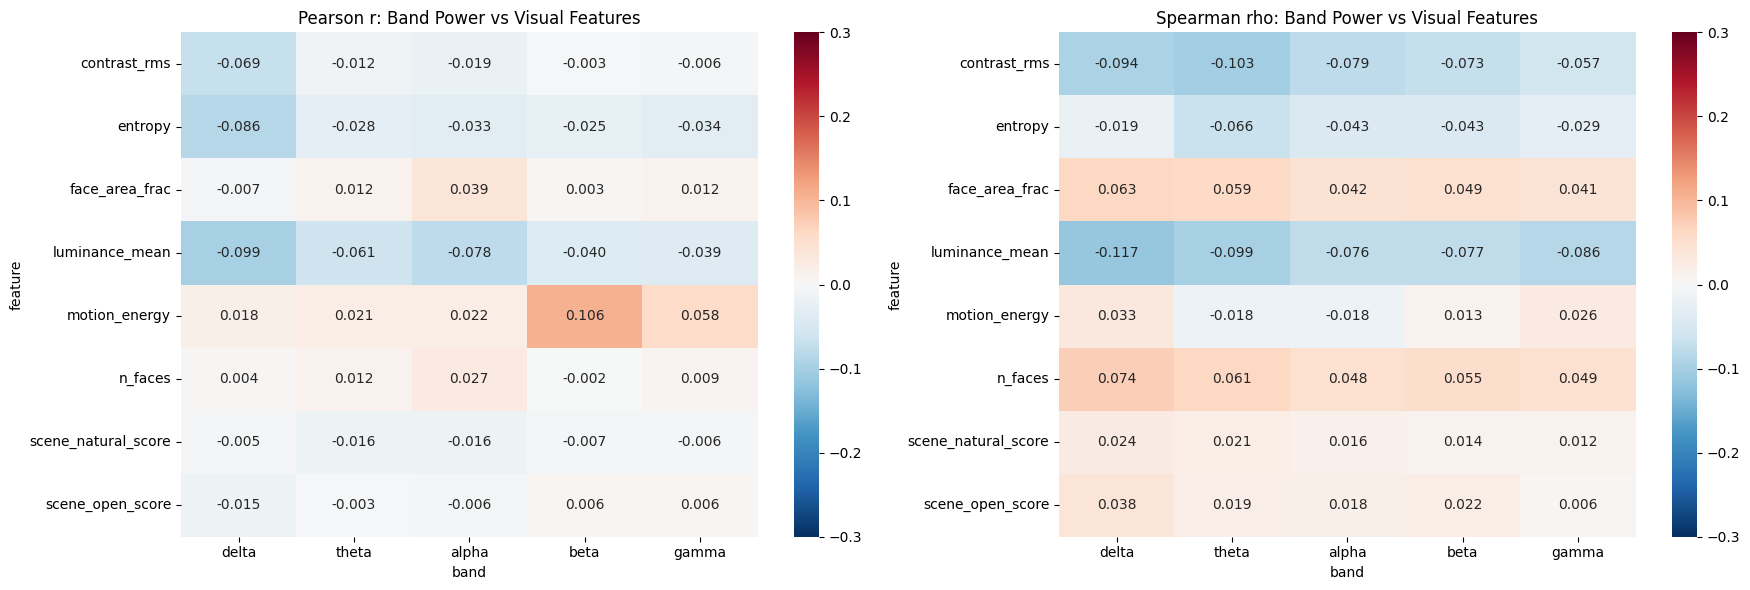


Significant correlations (p < 0.01): 7


,band,feature,pearson_r,pearson_p,spearman_rho,spearman_p,n_samples
27,beta,motion_energy,0.106467,0.000002,0.012576,5.721425e-01,2020
0,delta,luminance_mean,-0.098813,0.000009,-0.116694,1.444528e-07,2020
2,delta,entropy,-0.085670,0.000116,-0.019267,3.867688e-01,2020
16,alpha,luminance_mean,-0.078042,0.000447,-0.075675,6.641686e-04,2020
1,delta,contrast_rms,-0.068981,0.001922,-0.093999,2.321520e-05,2020
8,theta,luminance_mean,-0.061365,0.005800,-0.098868,8.518579e-06,2020
35,gamma,motion_energy,0.057703,0.009487,0.025845,2.456100e-01,2020


In [27]:
# Heatmap of correlations
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric, title in zip(
    axes,
    ["pearson_r", "spearman_rho"],
    ["Pearson r", "Spearman rho"],
):
    pivot = corr_df.pivot(index="feature", columns="band", values=metric)
    # Reorder bands
    pivot = pivot[["delta", "theta", "alpha", "beta", "gamma"]]
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
                ax=ax, vmin=-0.3, vmax=0.3)
    ax.set_title(f"{title}: Band Power vs Visual Features")

plt.tight_layout()
plt.show()

# Flag significant correlations
sig = corr_df[corr_df["pearson_p"] < 0.01].sort_values("pearson_r", key=abs, ascending=False)
if len(sig) > 0:
    print(f"\nSignificant correlations (p < 0.01): {len(sig)}")
    display(sig)
else:
    print("\nNo significant correlations found (p < 0.01).")
    print("This suggests the EEG may not contain linearly decodable visual feature info,")
    print("or the temporal alignment may be off.")

## 4. Per-Channel Correlation Map

Check if specific channels (e.g. occipital) show stronger correlations.
Focus on alpha band (strongest visual modulation) vs luminance.

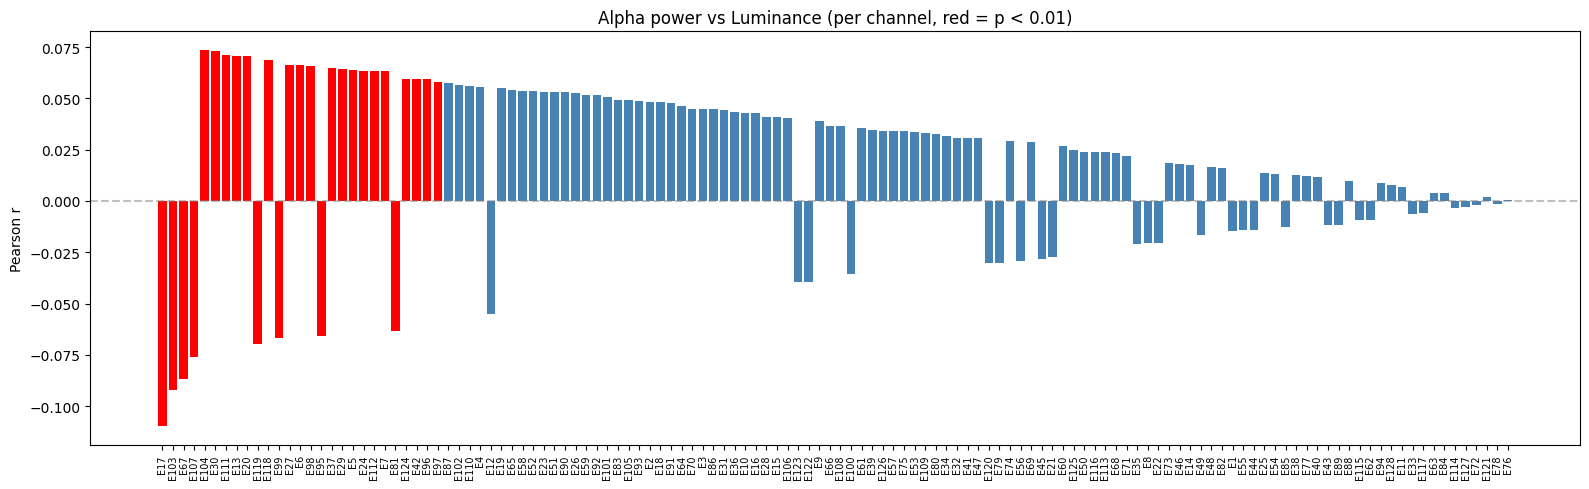


Top 10 channels by |correlation|:


,channel,pearson_r,p_value
16,E17,-0.109489,8.109074e-07
102,E103,-0.091978,3.471051e-05
66,E67,-0.086872,9.253178e-05
106,E107,-0.076120,6.170644e-04
103,E104,0.073502,9.465943e-04
29,E30,0.072945,1.035059e-03
110,E111,0.071222,1.359463e-03
12,E13,0.070463,1.530212e-03
19,E20,0.070458,1.531331e-03
118,E119,-0.069484,1.779521e-03


In [28]:
# Per-channel correlations for alpha power vs luminance
alpha_power = band_power["alpha"]  # (N, n_chans)
luminance = y_all["luminance_mean"]

ch_names = []
try:
    raw = train_ds.data.datasets[0].raw
    ch_names = raw.info["ch_names"]
except Exception:
    ch_names = [f"ch{i}" for i in range(n_chans)]

ch_corrs = []
for ch_idx in range(n_chans):
    r, p = pearsonr(alpha_power[:, ch_idx], luminance)
    ch_corrs.append({"channel": ch_names[ch_idx] if ch_idx < len(ch_names) else f"ch{ch_idx}",
                     "pearson_r": r, "p_value": p})

ch_corr_df = pd.DataFrame(ch_corrs).sort_values("pearson_r", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['red' if p < 0.01 else 'steelblue' for p in ch_corr_df['p_value']]
ax.bar(range(len(ch_corr_df)), ch_corr_df["pearson_r"], color=colors)
ax.set_xticks(range(len(ch_corr_df)))
ax.set_xticklabels(ch_corr_df["channel"], rotation=90, fontsize=7)
ax.set_ylabel("Pearson r")
ax.set_title("Alpha power vs Luminance (per channel, red = p < 0.01)")
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nTop 10 channels by |correlation|:")
ch_corr_df.head(10)

## 5. Temporal Alignment Check

Plot visual feature time series alongside EEG power (occipital average).
If alignment is correct, you should see co-fluctuation.

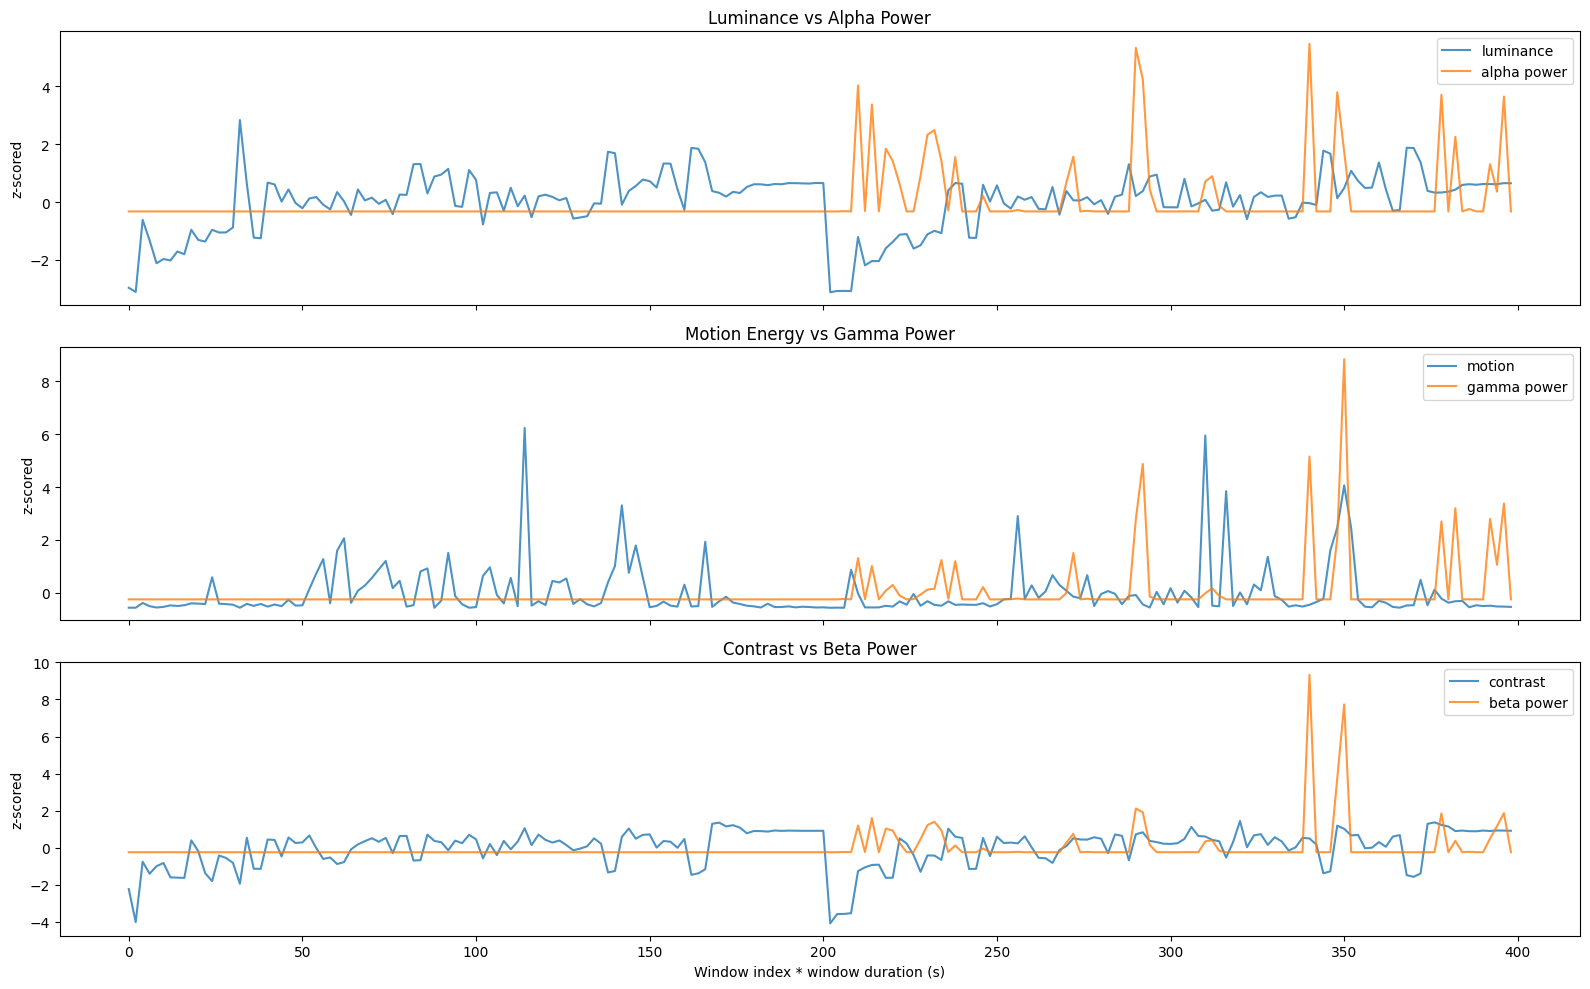

NOTE: Windows may span multiple subjects, so discontinuities are expected.
Look for local co-fluctuation within each subject's segment.


In [29]:
# We'll use the first ~100 windows as a time series from a single subject
# Need to extract contiguous windows from one recording
# For now, just plot all windows in order (they may span multiple subjects)

window_dur = n_times / sfreq
t_windows = np.arange(N) * window_dur  # approximate time axis

# Average gamma power across all channels (proxy for neural activity)
gamma_mean = band_power["gamma"].mean(axis=1)
alpha_mean = band_power["alpha"].mean(axis=1)

# Normalize for plotting
def zscore(x):
    return (x - x.mean()) / (x.std() + 1e-10)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Show first 200 windows (or all if fewer)
n_show = min(200, N)

axes[0].plot(t_windows[:n_show], zscore(y_all["luminance_mean"][:n_show]), 
             label="luminance", alpha=0.8)
axes[0].plot(t_windows[:n_show], zscore(alpha_mean[:n_show]),
             label="alpha power", alpha=0.8)
axes[0].set_ylabel("z-scored")
axes[0].set_title("Luminance vs Alpha Power")
axes[0].legend()

axes[1].plot(t_windows[:n_show], zscore(y_all["motion_energy"][:n_show]),
             label="motion", alpha=0.8)
axes[1].plot(t_windows[:n_show], zscore(gamma_mean[:n_show]),
             label="gamma power", alpha=0.8)
axes[1].set_ylabel("z-scored")
axes[1].set_title("Motion Energy vs Gamma Power")
axes[1].legend()

axes[2].plot(t_windows[:n_show], zscore(y_all["contrast_rms"][:n_show]),
             label="contrast", alpha=0.8)
axes[2].plot(t_windows[:n_show], zscore(band_power["beta"].mean(axis=1)[:n_show]),
             label="beta power", alpha=0.8)
axes[2].set_ylabel("z-scored")
axes[2].set_xlabel("Window index * window duration (s)")
axes[2].set_title("Contrast vs Beta Power")
axes[2].legend()

plt.tight_layout()
plt.show()

print("NOTE: Windows may span multiple subjects, so discontinuities are expected.")
print("Look for local co-fluctuation within each subject's segment.")

## 6. Scene Cut ERP

Average EEG locked to scene cuts (large motion/luminance transitions).
A clear visual evoked potential ~100-300ms post-cut confirms data quality.

Detected 200 high-motion windows (threshold: 3.0114)
Non-cut windows: 1820


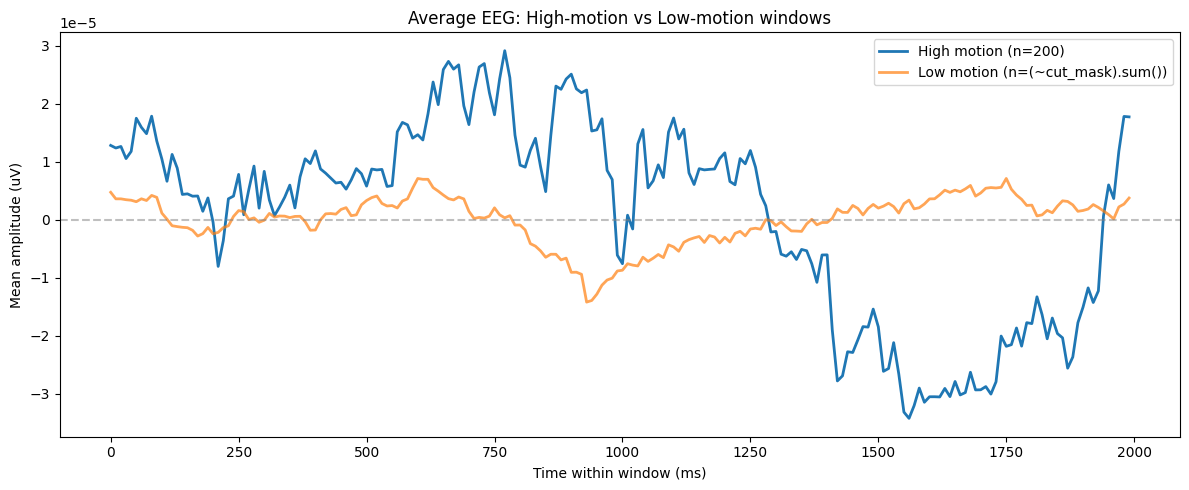

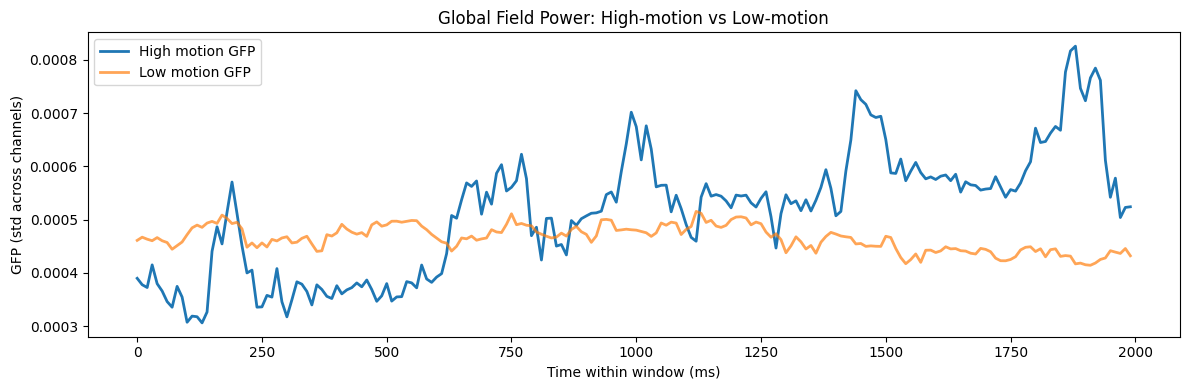

In [30]:
# Detect scene cuts: windows with high motion energy (top 10%)
motion = y_all["motion_energy"]
threshold = np.percentile(motion, 90)
cut_indices = np.where(motion > threshold)[0]

print(f"Detected {len(cut_indices)} high-motion windows (threshold: {threshold:.4f})")
print(f"Non-cut windows: {N - len(cut_indices)}")

# Average EEG waveform at cut vs non-cut windows
cut_mask = np.zeros(N, dtype=bool)
cut_mask[cut_indices] = True

avg_cut = X_all[cut_mask].mean(axis=(0, 1))     # average across windows and channels
avg_nocut = X_all[~cut_mask].mean(axis=(0, 1))

t_samples = np.arange(n_times) / sfreq * 1000  # ms

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_samples, avg_cut, label=f"High motion (n={cut_mask.sum()})", linewidth=2)
ax.plot(t_samples, avg_nocut, label=f"Low motion (n=(~cut_mask).sum())", linewidth=2, alpha=0.7)
ax.set_xlabel("Time within window (ms)")
ax.set_ylabel("Mean amplitude (uV)")
ax.set_title("Average EEG: High-motion vs Low-motion windows")
ax.legend()
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Also check GFP (global field power) difference
gfp_cut = np.std(X_all[cut_mask], axis=1).mean(axis=0)
gfp_nocut = np.std(X_all[~cut_mask], axis=1).mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_samples, gfp_cut, label="High motion GFP", linewidth=2)
ax.plot(t_samples, gfp_nocut, label="Low motion GFP", linewidth=2, alpha=0.7)
ax.set_xlabel("Time within window (ms)")
ax.set_ylabel("GFP (std across channels)")
ax.set_title("Global Field Power: High-motion vs Low-motion")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Binary Classification Feasibility

Median-split each feature into high/low classes.
Use band power features + logistic regression to test decodability.
Sham random feature should be at ~50% chance.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Build feature matrix: band power per channel, flattened
# (N, n_bands * n_chans)
X_bp = np.concatenate(
    [band_power[b] for b in ["delta", "theta", "alpha", "beta", "gamma"]],
    axis=1,
)
print(f"Band power feature matrix: {X_bp.shape}")

# Also add a sham random target
y_all["sham_random"] = np.random.uniform(-1, 1, size=N)

clf_results = []
all_features = list(FEATURES_OF_INTEREST) + ["sham_random"]

for feat_name in all_features:
    feat_vals = y_all[feat_name]
    valid = ~np.isnan(feat_vals)
    
    # Median split -> binary
    median = np.median(feat_vals[valid])
    y_binary = (feat_vals[valid] > median).astype(int)
    X_valid = X_bp[valid]
    
    # Skip if class is too imbalanced
    balance = y_binary.mean()
    if balance < 0.1 or balance > 0.9:
        clf_results.append({
            "feature": feat_name, "accuracy": np.nan,
            "accuracy_std": np.nan, "note": "too imbalanced",
        })
        continue
    
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs"),
    )
    
    scores = cross_val_score(pipe, X_valid, y_binary, cv=5, scoring="accuracy")
    
    clf_results.append({
        "feature": feat_name,
        "accuracy": scores.mean(),
        "accuracy_std": scores.std(),
        "n_samples": int(valid.sum()),
        "class_balance": f"{balance:.2f}",
    })
    print(f"  {feat_name:25s}: acc={scores.mean():.3f} +/- {scores.std():.3f}")

clf_df = pd.DataFrame(clf_results)
clf_df

Band power feature matrix: (2020, 645)
  luminance_mean           : acc=0.505 +/- 0.029
  contrast_rms             : acc=0.520 +/- 0.015
  entropy                  : acc=0.502 +/- 0.032
  motion_energy            : acc=0.481 +/- 0.022
  n_faces                  : acc=0.515 +/- 0.048
  face_area_frac           : acc=0.515 +/- 0.048
  scene_natural_score      : acc=0.505 +/- 0.015
  scene_open_score         : acc=0.490 +/- 0.014
  sham_random              : acc=0.484 +/- 0.008


,feature,accuracy,accuracy_std,n_samples,class_balance
0,luminance_mean,0.504950,0.028909,2020,0.50
1,contrast_rms,0.520297,0.014967,2020,0.50
2,entropy,0.502475,0.031891,2020,0.50
3,motion_energy,0.480693,0.022051,2020,0.50
4,n_faces,0.514851,0.047997,2020,0.40
5,face_area_frac,0.514851,0.047997,2020,0.40
6,scene_natural_score,0.504950,0.015016,2020,0.50
7,scene_open_score,0.490099,0.014002,2020,0.50
8,sham_random,0.483663,0.008074,2020,0.50


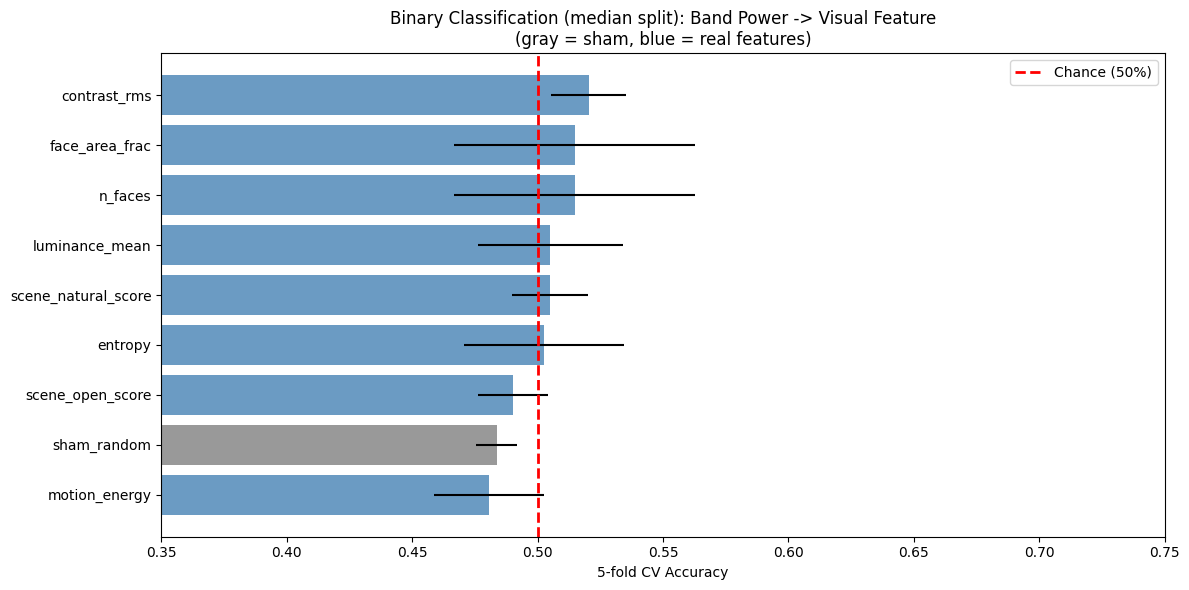


Sham accuracy: 0.484 (expect ~0.500)
Real feature accuracies: mean=0.504, max=0.520
Features clearly above chance: 5/8
-> Signal exists! Classification benchmark is viable.


In [12]:
# Visualize classification results
fig, ax = plt.subplots(figsize=(12, 6))

clf_plot = clf_df.dropna(subset=["accuracy"]).sort_values("accuracy", ascending=True)
colors = ['gray' if f == 'sham_random' else 'steelblue' for f in clf_plot['feature']]

bars = ax.barh(clf_plot["feature"], clf_plot["accuracy"], 
               xerr=clf_plot["accuracy_std"], color=colors, alpha=0.8)
ax.axvline(0.5, color="red", linestyle="--", linewidth=2, label="Chance (50%)")
ax.set_xlabel("5-fold CV Accuracy")
ax.set_title("Binary Classification (median split): Band Power -> Visual Feature\n"
             "(gray = sham, blue = real features)")
ax.legend()
ax.set_xlim(0.35, 0.75)
plt.tight_layout()
plt.show()

# Summary
sham_acc = clf_df[clf_df["feature"] == "sham_random"]["accuracy"].values[0]
real_accs = clf_df[clf_df["feature"] != "sham_random"]["accuracy"].dropna()
print(f"\nSham accuracy: {sham_acc:.3f} (expect ~0.500)")
print(f"Real feature accuracies: mean={real_accs.mean():.3f}, max={real_accs.max():.3f}")
above_chance = real_accs[real_accs > sham_acc + 0.02]
if len(above_chance) > 0:
    print(f"Features clearly above chance: {len(above_chance)}/{len(real_accs)}")
    print("-> Signal exists! Classification benchmark is viable.")
else:
    print("No features clearly above sham. Check data quality and alignment.")

## 8. Varying the Visual Processing Delay

The current delay is set to 0.3s. Sweep different delays and check if correlation peaks at a specific offset.
This directly tests temporal alignment.

In [13]:
# Load the raw feature CSV (frame-level) so we can re-align manually
from eb_jepa.datasets.hbn import MOVIE_METADATA

feature_csv = MOVIE_METADATA["ThePresent"]["feature_csv"]
movie_features_df = pd.read_csv(feature_csv)
print(f"Movie features: {len(movie_features_df)} frames")
print(f"Columns: {list(movie_features_df.columns)}")
movie_features_df.head()

Movie features: 4877 frames
Columns: ['luminance_mean', 'contrast_rms', 'color_r_mean', 'color_g_mean', 'color_b_mean', 'saturation_mean', 'edge_density', 'spatial_freq_energy', 'entropy', 'motion_energy', 'scene_cut', 'frame_idx', 'timestamp_s', 'n_faces', 'face_area_frac', 'depth_mean', 'depth_std', 'depth_range', 'n_objects', 'object_categories', 'scene_category', 'scene_category_score', 'scene_natural_score', 'scene_open_score']


,luminance_mean,contrast_rms,color_r_mean,color_g_mean,color_b_mean,saturation_mean,edge_density,spatial_freq_energy,entropy,motion_energy,...,face_area_frac,depth_mean,depth_std,depth_range,n_objects,object_categories,scene_category,scene_category_score,scene_natural_score,scene_open_score
0,0.004615,0.013511,0.004640,0.000696,0.008559,0.996694,0.000838,0.034625,0.048223,0.000000e+00,...,0.0,16.930498,6.456675,25.592134,0,{},bathroom,0.067519,0.023332,-0.021550
1,0.004615,0.013511,0.004746,0.000696,0.008665,0.996694,0.000838,0.034625,0.048223,5.626465e-08,...,0.0,17.340193,5.219767,20.754026,0,{},fantasy or animated world,0.067885,0.017630,-0.027515
2,0.004615,0.013511,0.004748,0.000696,0.008667,0.996694,0.000838,0.034625,0.048223,5.626465e-08,...,0.0,17.382896,5.185273,20.572771,0,{},fantasy or animated world,0.068009,0.017157,-0.028392
3,0.004615,0.013511,0.004748,0.000696,0.008667,0.996694,0.000838,0.034625,0.048223,5.626465e-08,...,0.0,17.384365,5.185468,20.571503,0,{},fantasy or animated world,0.068009,0.017157,-0.028392
4,0.004617,0.013511,0.004822,0.000698,0.008741,0.996591,0.000838,0.034632,0.053943,9.511935e-08,...,0.0,16.592028,3.959511,15.682379,0,{},fantasy or animated world,0.068213,0.017268,-0.032498


In [14]:
# For delay sweep, we need window onset times to recompute alignment.
# We'll use the first recording to get contiguous windows.
fps = MOVIE_METADATA["ThePresent"]["fps"]

# Get window onsets from the dataset
window_onsets = []  # in samples
for i in range(len(train_ds)):
    _, _, crop_inds = train_ds.data[i]
    window_onsets.append(crop_inds[1])  # i_start_in_trial

window_onsets = np.array(window_onsets)
print(f"Window onsets: {len(window_onsets)} windows")
print(f"Range: {window_onsets.min()} - {window_onsets.max()} samples")

Window onsets: 2020 windows
Range: 131 - 20467 samples


Sweeping delay: 100%|██████████| 40/40 [00:03<00:00, 12.36it/s]


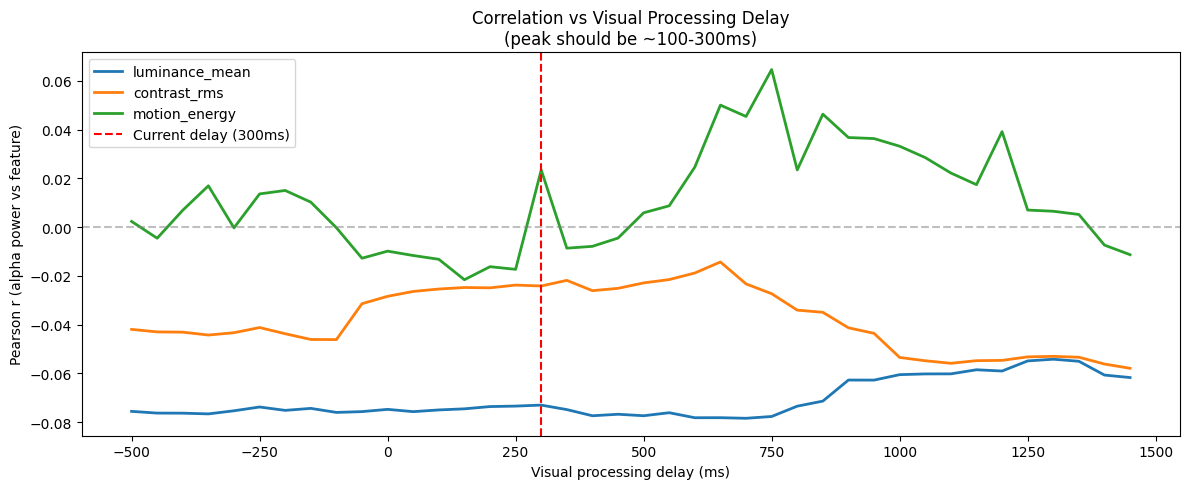

luminance_mean: peak |r|=0.0784 at delay=700ms
contrast_rms: peak |r|=0.0579 at delay=1450ms
motion_energy: peak |r|=0.0646 at delay=750ms


In [15]:
# Sweep visual processing delay
delays_s = np.arange(-0.5, 1.5, 0.05)  # -500ms to +1500ms
alpha_mean = band_power["alpha"].mean(axis=1)  # (N,)

delay_corrs = {feat: [] for feat in ["luminance_mean", "contrast_rms", "motion_energy"]}

# Current delay used when creating the dataset
current_delay = cfg.data.visual_processing_delay_s

for delay in tqdm(delays_s, desc="Sweeping delay"):
    # delta_delay = how much to shift from current alignment
    delta_delay = delay - current_delay
    delta_samples = int(delta_delay * sfreq)
    
    for feat_name in delay_corrs.keys():
        shifted_features = []
        for i, onset in enumerate(window_onsets):
            # Recompute frame index with this delay
            shifted_onset = onset - int(delta_delay * sfreq)
            movie_time = shifted_onset / sfreq
            frame_idx = int(movie_time * fps)
            frame_idx = max(0, min(frame_idx, len(movie_features_df) - 1))
            shifted_features.append(float(movie_features_df.iloc[frame_idx][feat_name]))
        
        shifted_features = np.array(shifted_features)
        valid = ~np.isnan(shifted_features)
        if valid.sum() > 10:
            r, _ = pearsonr(alpha_mean[valid], shifted_features[valid])
            delay_corrs[feat_name].append(r)
        else:
            delay_corrs[feat_name].append(0.0)

fig, ax = plt.subplots(figsize=(12, 5))
for feat_name, corrs in delay_corrs.items():
    ax.plot(delays_s * 1000, corrs, label=feat_name, linewidth=2)

ax.axvline(current_delay * 1000, color='red', linestyle='--', 
           label=f'Current delay ({current_delay*1000:.0f}ms)')
ax.set_xlabel("Visual processing delay (ms)")
ax.set_ylabel("Pearson r (alpha power vs feature)")
ax.set_title("Correlation vs Visual Processing Delay\n(peak should be ~100-300ms)")
ax.legend()
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Report optimal delays
for feat_name, corrs in delay_corrs.items():
    best_idx = np.argmax(np.abs(corrs))
    print(f"{feat_name}: peak |r|={abs(corrs[best_idx]):.4f} at delay={delays_s[best_idx]*1000:.0f}ms")

## 9. Summary & Recommendations

Based on the above analyses, determine:
1. Is there decodable signal? (band power correlations, classification accuracy)
2. Is the temporal alignment correct? (delay sweep peak)
3. Which features are most decodable? (for focused benchmarking)

In [16]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)

# 1. Band power correlations
max_corr = corr_df["pearson_r"].abs().max()
max_corr_row = corr_df.loc[corr_df["pearson_r"].abs().idxmax()]
print(f"\n1. Strongest band power correlation: |r|={max_corr:.4f}")
print(f"   ({max_corr_row['band']} vs {max_corr_row['feature']}, p={max_corr_row['pearson_p']:.2e})")
if max_corr > 0.1:
    print("   -> Good: meaningful linear relationship exists.")
elif max_corr > 0.05:
    print("   -> Weak signal. Classification may work but regression will struggle.")
else:
    print("   -> Very weak. Check alignment and data quality.")

# 2. Classification
best_real = clf_df[clf_df["feature"] != "sham_random"]["accuracy"].max()
print(f"\n2. Best binary classification accuracy: {best_real:.3f}")
print(f"   Sham accuracy: {sham_acc:.3f}")
if best_real > 0.55:
    print("   -> Classification is viable. Proceed with classification benchmark.")
elif best_real > 0.52:
    print("   -> Marginal. Signal exists but weak. Try with neural net models.")
else:
    print("   -> No clear signal. Debug data pipeline before benchmarking.")

# 3. Delay
print(f"\n3. Current visual processing delay: {current_delay*1000:.0f}ms")
for feat_name, corrs in delay_corrs.items():
    best_idx = np.argmax(np.abs(corrs))
    print(f"   Optimal for {feat_name}: {delays_s[best_idx]*1000:.0f}ms")

SUMMARY

1. Strongest band power correlation: |r|=0.1065
   (beta vs motion_energy, p=1.62e-06)
   -> Good: meaningful linear relationship exists.

2. Best binary classification accuracy: 0.520
   Sham accuracy: 0.484
   -> Marginal. Signal exists but weak. Try with neural net models.

3. Current visual processing delay: 300ms
   Optimal for luminance_mean: 700ms
   Optimal for contrast_rms: 1450ms
   Optimal for motion_energy: 750ms
